In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
# Load data
df = pd.read_csv("D:\FLIGHT PRICE PREDICTOR\BASE\indian\Clean_Dataset.csv")
print("Shape:", df.shape)
display(df.head())
display(df.isnull().sum())

Shape: (300153, 10)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,130.2,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,139.8,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130.2,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135.0,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,139.8,1,5955


airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [4]:
# Basic cleaning
df = df.drop_duplicates().copy()

# Standardize text columns
cat_cols_raw = ["airline", "source_city", "departure_time", "stops", "arrival_time", "destination_city", "class"]
for c in cat_cols_raw:
    df[c] = df[c].astype(str).str.strip().str.lower()

# Ensure numeric types
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["days_left"] = pd.to_numeric(df["days_left"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["duration", "days_left", "price"])
df = df[(df["duration"] > 0) & (df["days_left"] >= 0) & (df["price"] > 0)].copy()

print("Shape after clean:", df.shape)

Shape after clean: (297940, 10)


In [5]:
# Train/validation/test split
X = df.drop(columns=["price"]).copy()
y = df["price"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)

Train: (208558, 9) Valid: (44691, 9) Test: (44691, 9)


In [6]:
# Feature engineering function (no target leakage)
time_order = {
    "early_morning": 0,
    "morning": 1,
    "afternoon": 2,
    "evening": 3,
    "night": 4,
    "late_night": 5
}

stops_order = {"zero": 0, "one": 1, "two_or_more": 2}
class_order = {"economy": 0, "business": 1}

def build_features(base_df):
    out = base_df.copy()
    
    # Route features
    out["route"] = out["source_city"] + "_" + out["destination_city"]
    out["route_rev"] = out["destination_city"] + "_" + out["source_city"]
    out["is_same_city"] = (out["source_city"] == out["destination_city"]).astype(int)

    # Ordered features
    out["departure_time_ord"] = out["departure_time"].map(time_order).fillna(-1).astype(int)
    out["arrival_time_ord"] = out["arrival_time"].map(time_order).fillna(-1).astype(int)
    out["stops_ord"] = out["stops"].map(stops_order).fillna(3).astype(int)
    out["class_ord"] = out["class"].map(class_order).fillna(-1).astype(int)

    # Time interaction features
    out["dep_arr_diff_ord"] = (out["arrival_time_ord"] - out["departure_time_ord"]) % 6
    out["duration_per_stop"] = out["duration"] / (out["stops_ord"] + 1)
    out["duration_x_stops"] = out["duration"] * (out["stops_ord"] + 1)
    out["advance_booking_bucket"] = pd.cut(
        out["days_left"],
        bins=[-1, 2, 7, 15, 30, 60, 120, 365],
        labels=["very_last_min", "last_min", "short", "medium", "long", "very_long", "ultra_long"]
    ).astype(str)

    # Log-friendly numeric transforms
    out["log_duration"] = np.log1p(out["duration"])
    out["log_days_left"] = np.log1p(out["days_left"])

    return out

X_train_fe = build_features(X_train)
X_valid_fe = build_features(X_valid)
X_test_fe = build_features(X_test)

print("Feature engineered train shape:", X_train_fe.shape)
display(X_train_fe.head())

Feature engineered train shape: (208558, 22)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,route,...,departure_time_ord,arrival_time_ord,stops_ord,class_ord,dep_arr_diff_ord,duration_per_stop,duration_x_stops,advance_booking_bucket,log_duration,log_days_left
29254,vistara,delhi,afternoon,one,night,hyderabad,economy,484.8,6,delhi_hyderabad,...,2,4,1,0,2,242.4,969.6,last_min,6.185797,1.945910
12958,vistara,delhi,morning,one,evening,bangalore,economy,364.8,17,delhi_bangalore,...,1,3,1,0,2,182.4,729.6,medium,5.902087,2.890372
110557,air india,bangalore,afternoon,one,evening,hyderabad,economy,225.0,10,bangalore_hyderabad,...,2,3,1,0,1,112.5,450.0,short,5.420535,2.397895
52936,air india,mumbai,early_morning,one,late_night,bangalore,economy,990.0,2,mumbai_bangalore,...,0,5,1,0,5,495.0,1980.0,very_last_min,6.898715,1.098612
7927,indigo,delhi,early_morning,zero,early_morning,mumbai,economy,145.2,40,delhi_mumbai,...,0,0,0,0,0,145.2,145.2,long,4.984976,3.713572


In [8]:
# Frequency encoding learned only from train (safe)
freq_cols = ["airline", "source_city", "destination_city", "route"]

for col in freq_cols:
    freq_map = X_train_fe[col].value_counts(normalize=True)
    X_train_fe[col + "_freq"] = X_train_fe[col].map(freq_map).fillna(0.0)
    X_valid_fe[col + "_freq"] = X_valid_fe[col].map(freq_map).fillna(0.0)
    X_test_fe[col + "_freq"] = X_test_fe[col].map(freq_map).fillna(0.0)

In [11]:
# KFold target encoding for high-cardinality columns (leakage-controlled)
def kfold_target_encode(train_df, y_train_series, valid_df, test_df, col, n_splits=5, smoothing=20):
    train_encoded = pd.Series(index=train_df.index, dtype=float)
    global_mean = y_train_series.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for tr_idx, val_idx in kf.split(train_df):
        tr_x = train_df.iloc[tr_idx]
        tr_y = y_train_series.iloc[tr_idx]
        va_x = train_df.iloc[val_idx]

        stats = tr_x.groupby(col).apply(
            lambda g: pd.Series({
                "count": len(g),
                "mean": tr_y.loc[g.index].mean()
            })
        )
        stats["smooth"] = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        mapping = stats["smooth"].to_dict()

        train_encoded.iloc[val_idx] = va_x[col].map(mapping).fillna(global_mean).values

    # Full-train mapping for valid/test
    full_stats = train_df.groupby(col).apply(
        lambda g: pd.Series({
            "count": len(g),
            "mean": y_train_series.loc[g.index].mean()
        })
    )
    full_stats["smooth"] = (full_stats["count"] * full_stats["mean"] + smoothing * global_mean) / (full_stats["count"] + smoothing)
    full_map = full_stats["smooth"].to_dict()

    valid_encoded = valid_df[col].map(full_map).fillna(global_mean)
    test_encoded = test_df[col].map(full_map).fillna(global_mean)

    return train_encoded, valid_encoded, test_encoded

high_card_cols = [ "route"]
for c in high_card_cols:
    tr_e, va_e, te_e = kfold_target_encode(X_train_fe, y_train, X_valid_fe, X_test_fe, c, n_splits=5, smoothing=30)
    X_train_fe[c + "_te"] = tr_e
    X_valid_fe[c + "_te"] = va_e
    X_test_fe[c + "_te"] = te_e

C:\Users\adilp\AppData\Local\Temp\ipykernel_12816\1442819091.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = tr_x.groupby(col).apply(
C:\Users\adilp\AppData\Local\Temp\ipykernel_12816\1442819091.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = tr_x.groupby(col).apply(
C:\Users\adilp\AppData\Local\Temp\ipykernel_12816\1442819091.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grou

In [12]:
# Outlier clipping learned from train only
num_clip_cols = ["duration", "days_left", "log_duration", "log_days_left", "duration_per_stop", "duration_x_stops"]

clip_bounds = {}
for c in num_clip_cols:
    low, high = X_train_fe[c].quantile([0.01, 0.99])
    clip_bounds[c] = (low, high)
    X_train_fe[c] = X_train_fe[c].clip(low, high)
    X_valid_fe[c] = X_valid_fe[c].clip(low, high)
    X_test_fe[c] = X_test_fe[c].clip(low, high)

clip_bounds

{'duration': (79.8, 1744.8),
 'days_left': (2.0, 49.0),
 'log_duration': (4.39197696552705, 7.4649681823012495),
 'log_days_left': (1.0986122886681098, 3.912023005428146),
 'duration_per_stop': (79.8, 849.9),
 'duration_x_stops': (79.8, 4064.3999999999996)}

In [15]:
# Build preprocessing pipeline
# Drop raw high-card columns after deriving encoded versions
drop_cols = ["flight", "route_rev"]  # keep route for one-hot + TE if you want, can drop as well
X_train_model = X_train_fe.drop(columns=drop_cols, errors="ignore")
X_valid_model = X_valid_fe.drop(columns=drop_cols, errors="ignore")
X_test_model = X_test_fe.drop(columns=drop_cols, errors="ignore")

categorical_cols = X_train_model.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train_model.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False, min_frequency=0.005), categorical_cols),
    ]
)

model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=10,
    max_iter=600,
    min_samples_leaf=20,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))

Numeric cols: 17
Categorical cols: 9


In [16]:
# Train and evaluate
pipe.fit(X_train_model, y_train)

pred_valid = pipe.predict(X_valid_model)
pred_test = pipe.predict(X_test_model)

def report(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

report(y_valid, pred_valid, "Validation")
report(y_test, pred_test, "Test")

Validation -> RMSE: 3433.18 | MAE: 1954.92 | R2: 0.9771
Test -> RMSE: 3470.51 | MAE: 1971.53 | R2: 0.9768


In [17]:
# Imports for model training/tuning/comparison/save
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet

In [18]:
# Helper metric function
def evaluate(y_true, y_pred, tag="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{tag} -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return {"model": tag, "RMSE": rmse, "MAE": mae, "R2": r2}

In [21]:
# Build a clean preprocessor from engineered train set
# (Assumes you already created X_train_model, X_valid_model, X_test_model in FE cells)

categorical_cols = X_train_model.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train_model.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False, min_frequency=0.005), categorical_cols),
    ]
)

print("Numeric:", len(numeric_cols), "| Categorical:", len(categorical_cols))

Numeric: 17 | Categorical: 9


In [22]:
# Baseline model: HistGradientBoosting
baseline = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=10,
        max_iter=600,
        min_samples_leaf=20,
        random_state=42
    ))
])

baseline.fit(X_train_model, y_train)
val_pred_baseline = baseline.predict(X_valid_model)
test_pred_baseline = baseline.predict(X_test_model)

baseline_val_metrics = evaluate(y_valid, val_pred_baseline, "Baseline HGBR (valid)")
baseline_test_metrics = evaluate(y_test, test_pred_baseline, "Baseline HGBR (test)")

Baseline HGBR (valid) -> RMSE: 3433.18 | MAE: 1954.92 | R2: 0.9771
Baseline HGBR (test) -> RMSE: 3470.51 | MAE: 1971.53 | R2: 0.9768


In [23]:
# Hyperparameter tuning (RandomizedSearchCV) on train only
search_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

param_dist = {
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [6, 8, 10, 12, None],
    "model__max_iter": [300, 500, 700, 900],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0.0, 0.1, 0.3, 1.0]
}

search = RandomizedSearchCV(
    estimator=search_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_model, y_train)

print("Best Params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

best_hgbr = search.best_estimator_
val_pred_best = best_hgbr.predict(X_valid_model)
test_pred_best = best_hgbr.predict(X_test_model)

best_val_metrics = evaluate(y_valid, val_pred_best, "Tuned HGBR (valid)")
best_test_metrics = evaluate(y_test, test_pred_best, "Tuned HGBR (test)")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'model__min_samples_leaf': 50, 'model__max_iter': 900, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}
Best CV RMSE: 3131.0102221870798
Tuned HGBR (valid) -> RMSE: 3007.25 | MAE: 1659.84 | R2: 0.9824
Tuned HGBR (test) -> RMSE: 3030.98 | MAE: 1668.50 | R2: 0.9823


In [24]:
# Compare with additional models
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=350,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

en_model = Pipeline([
    ("prep", preprocessor),
    ("model", ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=42))
])

results = []

rf_model.fit(X_train_model, y_train)
rf_val_pred = rf_model.predict(X_valid_model)
results.append(evaluate(y_valid, rf_val_pred, "RandomForest (valid)"))

en_model.fit(X_train_model, y_train)
en_val_pred = en_model.predict(X_valid_model)
results.append(evaluate(y_valid, en_val_pred, "ElasticNet (valid)"))

results.append(best_val_metrics)

leaderboard = pd.DataFrame(results).sort_values("RMSE")
display(leaderboard)

RandomForest (valid) -> RMSE: 2845.79 | MAE: 1306.00 | R2: 0.9842


C:\Users\adilp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.552e+12, tolerance: 1.079e+10
  model = cd_fast.enet_coordinate_descent(


ElasticNet (valid) -> RMSE: 6580.04 | MAE: 4433.97 | R2: 0.9157


,model,RMSE,MAE,R2
0,RandomForest (valid),2845.787648,1306.001147,0.984238
2,Tuned HGBR (valid),3007.247886,1659.842172,0.982398
1,ElasticNet (valid),6580.036304,4433.971798,0.915730


In [26]:
# Error analysis on validation set using best tuned model
val_df = X_valid_model.copy()
val_df["actual_price"] = y_valid.values
val_df["pred_price"] = val_pred_best
val_df["residual"] = val_df["actual_price"] - val_df["pred_price"]
val_df["abs_error"] = np.abs(val_df["residual"])

print("Top rows with largest error:")
display(val_df.sort_values("abs_error", ascending=False).head(10))

Top rows with largest error:


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,route,...,log_days_left,airline_freq,source_city_freq,destination_city_freq,route_freq,route_te,actual_price,pred_price,residual,abs_error
267529,vistara,kolkata,evening,one,morning,bangalore,business,964.8,5,kolkata_bangalore,...,1.791759,0.426826,0.155161,0.170312,0.033041,22934.525633,105638,68591.280270,37046.719730,37046.719730
296081,vistara,chennai,early_morning,one,night,kolkata,business,949.8,5,chennai_kolkata,...,1.791759,0.426826,0.129307,0.164846,0.023356,22692.529465,102384,65917.039184,36466.960816,36466.960816
264121,vistara,kolkata,morning,two_or_more,night,mumbai,business,600.0,4,kolkata_mumbai,...,1.609438,0.426826,0.155161,0.197322,0.038445,21879.570565,110936,76184.385441,34751.614559,34751.614559
290691,vistara,chennai,night,one,morning,mumbai,business,870.0,7,chennai_mumbai,...,2.079442,0.426826,0.129307,0.197322,0.031425,22953.264415,105744,71142.549556,34601.450444,34601.450444
269090,vistara,kolkata,evening,one,morning,bangalore,business,835.2,30,kolkata_bangalore,...,3.433987,0.426826,0.155161,0.170312,0.033041,22934.525633,97709,63614.965625,34094.034375,34094.034375
261231,air india,bangalore,early_morning,one,night,chennai,business,900.0,49,bangalore_chennai,...,3.912023,0.271320,0.173616,0.133958,0.021361,23465.959846,26682,60306.810473,-33624.810473,33624.810473
290567,vistara,chennai,early_morning,one,night,mumbai,business,790.2,5,chennai_mumbai,...,1.791759,0.426826,0.129307,0.197322,0.031425,22953.264415,109776,76612.269439,33163.730561,33163.730561
291017,vistara,chennai,night,one,morning,mumbai,business,844.8,12,chennai_mumbai,...,2.564949,0.426826,0.129307,0.197322,0.031425,22953.264415,101152,68921.662443,32230.337557,32230.337557
229781,vistara,mumbai,morning,one,night,delhi,business,625.2,47,mumbai_delhi,...,3.871201,0.426826,0.202227,0.190853,0.048840,18778.351107,80458,48616.599687,31841.400313,31841.400313
284754,vistara,hyderabad,night,one,morning,kolkata,business,720.0,37,hyderabad_kolkata,...,3.637586,0.426826,0.136605,0.164846,0.026496,20975.437169,89642,58216.147009,31425.852991,31425.852991


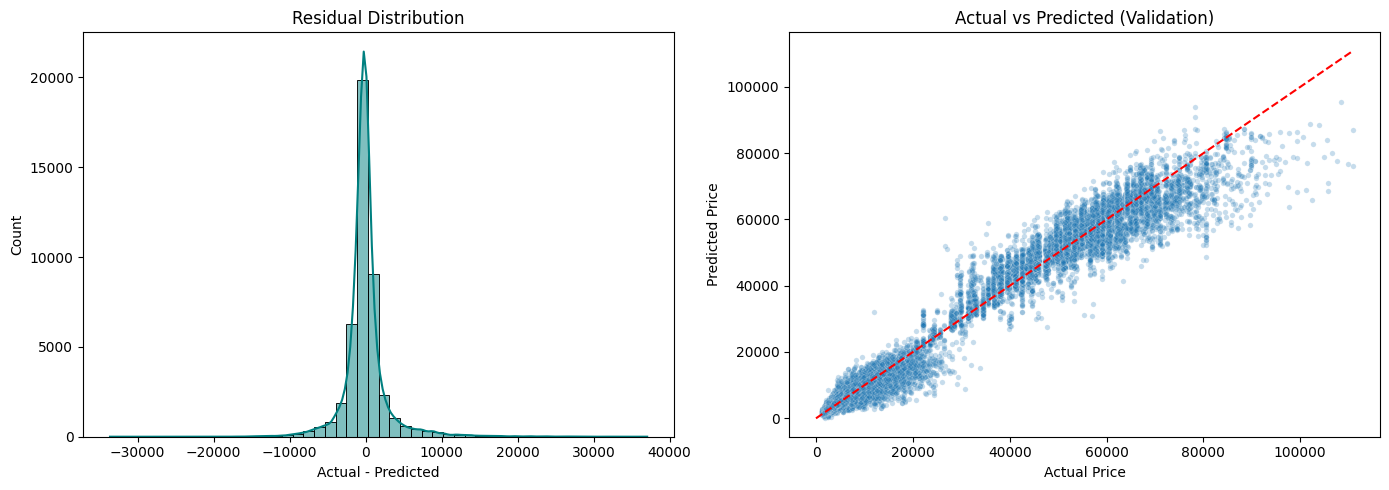

In [27]:
# Residual distribution + actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(val_df["residual"], kde=True, bins=50, ax=axes[0], color="teal")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual - Predicted")

sns.scatterplot(x=val_df["actual_price"], y=val_df["pred_price"], alpha=0.25, s=15, ax=axes[1])
min_v = min(val_df["actual_price"].min(), val_df["pred_price"].min())
max_v = max(val_df["actual_price"].max(), val_df["pred_price"].max())
axes[1].plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--")
axes[1].set_title("Actual vs Predicted (Validation)")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

In [28]:
# Group-wise error analysis (where model fails)
group_cols = ["airline", "class", "stops", "source_city", "destination_city"]

for col in group_cols:
    grp = val_df.groupby(col, as_index=False).agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        n=("abs_error", "size")
    ).sort_values("mean_abs_error", ascending=False)
    
    print(f"\nTop error groups by {col}:")
    display(grp.head(10))


Top error groups by airline:


,airline,mean_abs_error,median_abs_error,n
5,vistara,2226.921338,1117.403395,18835
0,air india,1526.361552,824.681579,12164
4,spicejet,1124.404424,629.716677,1340
3,indigo,1054.876537,656.715576,6474
2,go first,927.698759,522.308251,3448
1,airasia,878.437550,498.814774,2430



Top error groups by class:


,class,mean_abs_error,median_abs_error,n
0,business,3084.872501,1796.939404,13898
1,economy,1016.674195,634.236080,30793



Top error groups by stops:


,stops,mean_abs_error,median_abs_error,n
0,one,1784.353220,924.124118,37572
1,two_or_more,1457.784939,801.779367,1888
2,zero,838.460975,394.772329,5231



Top error groups by source_city:


,source_city,mean_abs_error,median_abs_error,n
1,chennai,1762.440429,931.479062,5743
5,mumbai,1748.241963,805.558789,9089
2,delhi,1640.921028,852.688134,9105
0,bangalore,1608.710155,788.189027,7683
3,hyderabad,1600.848372,850.544698,6074
4,kolkata,1592.779883,792.787342,6997



Top error groups by destination_city:


,destination_city,mean_abs_error,median_abs_error,n
4,kolkata,1819.701791,910.909220,7435
5,mumbai,1693.983188,795.428346,8787
0,bangalore,1668.169209,845.677380,7460
2,delhi,1629.499400,824.346655,8528
3,hyderabad,1572.526371,810.334080,6332
1,chennai,1539.655761,818.003388,6149


In [29]:
# Final training on train + valid, then final test evaluation
X_train_final = pd.concat([X_train_model, X_valid_model], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

final_model = best_hgbr
final_model.fit(X_train_final, y_train_final)

final_test_pred = final_model.predict(X_test_model)
final_test_metrics = evaluate(y_test, final_test_pred, "Final Model (test)")

Final Model (test) -> RMSE: 3009.43 | MAE: 1647.05 | R2: 0.9825


In [32]:
# Save and load model pipeline
import joblib
model_path = "D:\\FLIGHT PRICE PREDICTOR\\MODELS\\indian_flight_best_pipeline.joblib"
joblib.dump(final_model, model_path)
print("Saved:", model_path)

loaded_model = joblib.load(model_path)
loaded_pred = loaded_model.predict(X_test_model.head(5))
print("Loaded model sample preds:", loaded_pred)

Saved: D:\FLIGHT PRICE PREDICTOR\MODELS\indian_flight_best_pipeline.joblib
Loaded model sample preds: [57613.11712793  3448.89895337  5604.6125782  53062.3937837
  4009.67313288]
